## Convolutional Neural Network - Pytorch - Handwriting Image Classification on MNIST Dataset
CNNs excel at pattern recognition tasks, such as digitizing handwritten EHRs, prescriptions, and clinical forms.  

### Code Attribution 
<ul>
  <li> Title: Machine Learning with Python Cookbook 
  <li> Author: Kyle Gallatin & Chris Albon
  <li> Date: 23 November 2025
  <li> Modified By: Charlotte Alley
  <li> Description: Neural Networks for Unstructured Data  

<ul>
  <li> Title: Normalization in the mnist example 
  <li> Author: discuss.pytorch.org
  <li> Date: 23 November 2025
  <li> Modified By: Charlotte Alley
  <li> Description: The normalization and unnormalization procedure used in the MNIST dataset processing follows the approach described in the PyTorch Forums discussion on MNIST normalization

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchmetrics.classification import ConfusionMatrix
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

## Preprocessing and Loading Dataset 
The setup converts the 28x28 pixel images found in the MNIST dataset to tensors. Tensors are multi-dimensional arrays that generalize scalars, vectors, and matrices to any number of dimensions. This format preserves the spatial layout of the image, and allows for efficient vectorized operations and parallelization. The tensors are then standardized for neural network training, by subtracting the dataset mean (0.1307) and dividing by the standard deviation (0.3081). The order of this preprocessing is important, as the values will be incorrect if normalization is applied first. Normalizing before training prevents exploding gradients, and converts the training data into a form that the model will understand and expect. 

In [2]:
# Defines preprocessing steps before loading dataset for model preparation 
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.1307,), (0.3081,))
])

In [3]:
# Loads MNIST dataset into seperate training and testing variables
train_dataset = datasets.MNIST('./data', train=True, download=True, 
                               transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)

## First Five Images and Their Labels
Although it seems counterintuitive to unnormalize something that was just normalized, the normalized data is for training the neural network. The unnormalized data is for human visualization via matplotlib. 

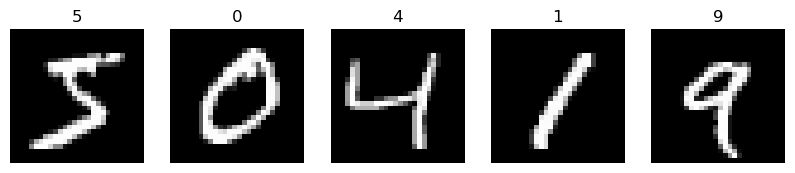

In [4]:
def unnormalize(img):
    # Normalization was included in the preprocessing for model purposes, but 
    # unnormalization is required to properly display the images
    # Reverses normalization applied in previous step
    img = img * 0.3081 + 0.1307
    # Removes unnecessary channel dimension
    img = img.squeeze(0) 
    # Converts PyTorch tensor to NumPy array for matplotlib compatibility
    npimg = img.numpy()
    plt.imshow(npimg, cmap='gray')
    plt.axis('off')

# Displays first 5 images and labels from train_dataset
plt.figure(figsize=(10,2))
for i in range(5):
    image, label = train_dataset[i]
    plt.subplot(1, 5, i+1)
    unnormalize(image)
    plt.title(label)
plt.show()

## CNN Classifier
CNN extracts hierarchical features, such as pixels, edges, and shapes, through convolutional and pooling layers. Convolutional layers slide learnable filters across images to detect local patterns such as edges (conv1) and shapes (conv2), creating feature maps that capture spatial hierarchies. Pooling layers downsample these maps by taking the max values in 2x2 regions, halving resolution (28x28 to 14x14) while preserving dominant features and adding translation invariance. So, convolution extracts and pooling summarizes. Once features have been extracted, classification occurs. 

In [5]:
# Defines neural network class Net, inherits base class from PyTorch’s nn.Module
class Net(nn.Module): 
    def __init__(self): 
        # Calls constructor of parent class nn.Module 
        super(Net, self).__init__()
        # Defines convolutional layers, second layer takes previous layer's 
        # output of 32
        self.conv1 = nn.Conv2d(1, 32, kernel_size=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Establishes dropout layers, 25% for first, 50% for second to randomly
        # deactivate neurons, increases regularization during training and 
        # reduces overfitting
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        # Establishes fully connected layers
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)

# Defines forward pass computation, determines how input x flows through layers
    def forward(self, x): 
        # Applies convolutions
        x = nn.functional.relu(self.conv1(x))
        x = nn.functional.relu(self.conv2(x))
        # Applies dropout and 2x2 max pooling, reduces spatial size by half, 
        # extracts dominant features
        x = nn.functional.max_pool2d(self.dropout1(x), 2)
        # Flattens output tensor for fully connected layers
        x = torch.flatten(x, 1)
        x = nn.functional.relu(self.fc1(self.dropout2(x)))
        x = self.fc2(x)
        # Applies final fully connected layer, produces logits for each class
        return nn.functional.log_softmax(x, dim=1)

In [6]:
# Sets device to run on 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# Creates data loaders 
batch_size = 64 
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, 
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, 
                                          shuffle=True)

In [8]:
# Initializes model and optimizer 
model = Net().to(device)
optimizer = optim.Adam(model.parameters())

In [9]:
# Compiles model using torch 2.0's optimizer
model = torch.compile(model)

## Model Train and Evaluation
A forward pass is made in training mode, computing predictions. Evaluations are calculated to compute test loss/accuracy and collect predictions for the confusion matrix analysis. 

In [10]:
# Defines training loop, sets model to training mode
model.train()

# Iterates over mini-batches from training dataloader, data contains input 
# tensors, target contains true labels 
for batch_idx, (data, target) in enumerate(train_loader): 
    # Moves input data and labels to computing device .
    data, target = data.to(device), target.to(device)
    # Clears old gradients from previous step, to avoid accumulation
    optimizer.zero_grad()
    # Feeds input batch data through model for predictions
    output = model(data)
    # Calculates negative log likelihood loss between predictions output and 
    # true labels target
    loss = nn.functional.nll_loss(output, target)
    # Performs backpropagation, computes gradients of loss
    loss.backward()
    # Updates model parameters using computed gradients
    optimizer.step()

Accuracy: 98%


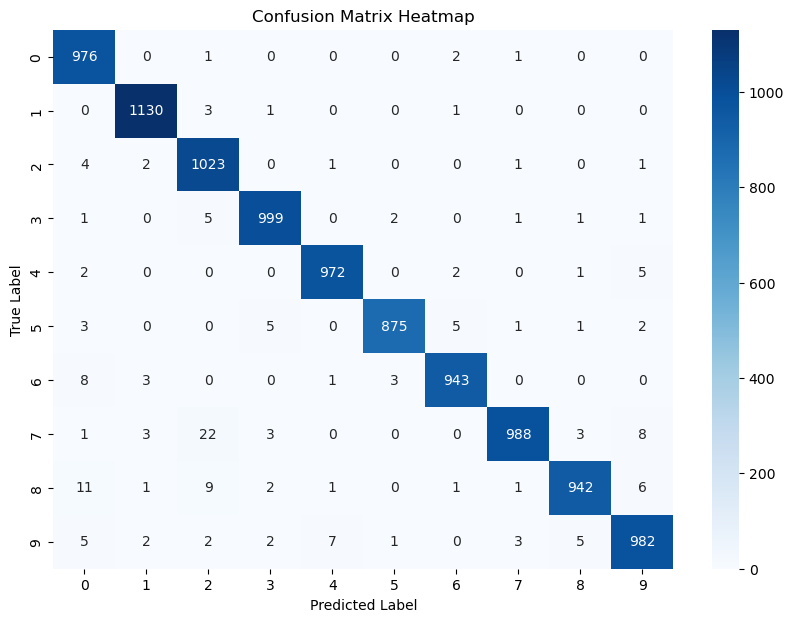

In [11]:
# Switches to evaluation mode 
model.eval()
# Initializes variable to accumulate total loss over test dataset
test_loss = 0
# Initializes variable to count number of correct predictions
correct = 0
# Establishes empty list to store predictions
all_preds = []
# Establishes empty list to store true labels
all_labels = []

with torch.no_grad():
    # Iterates over batches of inputs and true labels from test data loader
    for data, target in test_loader:
        # Moves batch tensors to device where model is deployed
        data, target = data.to(device), target.to(device)
        # Performs forward pass for model predictions on batch
        output = model(data)
        # Computes negative log likelihood loss for batch, summing over batch 
        # elements, accumulates
        test_loss += nn.functional.nll_loss(
            output, target, reduction='sum').item()
        # Gets predicted class indices, selects class with highest log prob for 
        # each example
        pred = output.argmax(dim=1, keepdim=False)
        # Counts how many predictions match true labels, accumulates
        correct += pred.eq(target).sum().item()
        # Collects batch predictions and true labels for confusion matrix 
        all_preds.append(pred)
        all_labels.append(target)

# Averages total test loss over all samples
test_loss /= len(test_loader.dataset)
accuracy = 100. * correct / len(test_loader.dataset)
print(f'Accuracy: {accuracy:.0f}%')

# Concatenates all batches
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Computes confusion matrix for MNIST
confmat = ConfusionMatrix(task="multiclass", num_classes=10)
confusion_matrix = confmat(all_preds, all_labels)

# Converts confusion matrix tensor to numpy array for plotting
cm = confusion_matrix.cpu().numpy()

# Creates dataframe for visualization
df_cm = pd.DataFrame(cm, index=[i for i in range(10)], 
                     columns=[i for i in range(10)])

# Plots confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Conclusion
The results indicate that the model is robust for MNIST digit identification, with an accuracy score of 98%. The confusion matrix shows a strong diagonal representing true labels that matched the predicted labels, and values for misidentifications are low. The highest misidentification values were for digits that resembled each other in shape, such as 7 and 2 and 0 and 8. 